# Raw-Feature Multilevel Regression: City Group

This notebook fits multilevel regression using raw standardized urban-form features and `City` as the grouping variable.

Main model:

`performance_score ~ selected raw urban-form features + (1 | City)`

It also includes an adjustable random-slope plotting workflow for selected planning variables.

In [2]:
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.options.display.float_format = '{:.4f}'.format
sns.set_theme(style='whitegrid')

OUT_DIR = '../output/multilevel_regression_raw_city'
os.makedirs(OUT_DIR, exist_ok=True)

TARGET = 'performance_score'
GROUP_COL = 'City'
VIF_THRESHOLD = 5.0
CORR_THRESHOLD = 0.90

## 1. Load Data

In [3]:
grid500 = pd.read_csv('../data/grid500_performance_score.csv', index_col=0)

features = [
    'buildingCount', 'totalHeight', 'avgHeight', 'basePerimeterTotal',
    'basePerimeterAvg', 'compactness', 'footprintAreaTotal', 'totalArea',
    'avgBuildingArea', 'FAR', 'coverageRatio',
    'roadDensity', 'intersectionDensity', 'poiDensity', 'poiDiversity',
    'FVC', 'permeableRatio', 'maxHeight', 'minHeight', 'heightRange', 'heightIndex',
    'heightDensity', 'heightOtherness', 'cornerCountTotal', 'basePerimeterMax',
    'basePerimeterMin', 'shapeComplexity', 'areaVariance', 'parcelArea',
    'largestPatchIndex', 'shape3DIndex', 'evennessIndex', 'cornerCountAvg',
    'buildingProximity', 'buildingMinDist', 'buildingMaxDist',
    'buildingDistAvg', 'buildingDistVar', 'SVF', 'streetRatio'
]

required_cols = [TARGET, GROUP_COL] + features
missing_cols = [c for c in required_cols if c not in grid500.columns]
if missing_cols:
    raise ValueError(f'Missing required columns: {missing_cols}')

df = (
    grid500[required_cols]
    .replace([np.inf, -np.inf], np.nan)
    .dropna()
    .copy()
)
df[GROUP_COL] = df[GROUP_COL].astype('category')

print('Rows:', len(df))
print('Cities:', df[GROUP_COL].nunique())
display(df[TARGET].describe())
display(df.groupby(GROUP_COL)[TARGET].agg(['count', 'mean', 'std']).head())

Rows: 194941
Cities: 36


count   194941.0000
mean         0.6593
std          0.1372
min          0.0000
25%          0.5852
50%          0.6763
75%          0.7538
max          1.0000
Name: performance_score, dtype: float64

,count,mean,std
City,,,
Beijing,14617,0.5889,0.1119
Changchun,5892,0.6345,0.1383
Changsha,3324,0.7022,0.1140
Chengdu,7570,0.7150,0.1030
Chongqing,6498,0.6785,0.1170


## 2. Feature Screening

In [4]:
def correlation_prune(data, cols, threshold=0.90):
    corr = data[cols].corr().abs()
    upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    drop_cols = [col for col in upper.columns if any(upper[col] > threshold)]
    keep_cols = [col for col in cols if col not in drop_cols]
    return keep_cols, drop_cols, corr


def calculate_vif_table(data, cols):
    X = data[cols].astype(float).copy()
    X = pd.DataFrame(StandardScaler().fit_transform(X), columns=cols, index=X.index)
    X = sm.add_constant(X)

    rows = []
    for i, col in enumerate(X.columns):
        if col == 'const':
            continue
        rows.append({'feature': col, 'VIF': variance_inflation_factor(X.values, i)})
    return pd.DataFrame(rows).sort_values('VIF', ascending=False)


def vif_prune(data, cols, threshold=5.0, min_features=8):
    keep = list(cols)
    dropped = []

    while len(keep) > min_features:
        vif_table = calculate_vif_table(data, keep)
        max_vif = vif_table['VIF'].max()
        if max_vif <= threshold:
            break

        worst_feature = vif_table.iloc[0]['feature']
        dropped.append((worst_feature, max_vif))
        keep.remove(worst_feature)

    return keep, pd.DataFrame(dropped, columns=['feature', 'VIF_when_dropped'])


corr_keep, corr_dropped, corr_matrix = correlation_prune(df, features, threshold=CORR_THRESHOLD)
selected_features, vif_dropped = vif_prune(df, corr_keep, threshold=VIF_THRESHOLD, min_features=8)
final_vif = calculate_vif_table(df, selected_features)

pd.Series(corr_dropped, name='dropped_by_correlation').to_csv(f'{OUT_DIR}/dropped_by_correlation.csv', index=False)
vif_dropped.to_csv(f'{OUT_DIR}/dropped_by_vif.csv', index=False)
final_vif.to_csv(f'{OUT_DIR}/final_vif_table.csv', index=False)
corr_matrix.to_csv(f'{OUT_DIR}/candidate_feature_correlation_matrix.csv')

print('Selected feature count:', len(selected_features))
print(selected_features)
display(vif_dropped)
display(final_vif)

Selected feature count: 27
['buildingCount', 'compactness', 'footprintAreaTotal', 'avgBuildingArea', 'roadDensity', 'intersectionDensity', 'poiDensity', 'poiDiversity', 'FVC', 'permeableRatio', 'maxHeight', 'minHeight', 'heightIndex', 'heightOtherness', 'basePerimeterMax', 'basePerimeterMin', 'shapeComplexity', 'areaVariance', 'parcelArea', 'largestPatchIndex', 'shape3DIndex', 'evennessIndex', 'cornerCountAvg', 'buildingMinDist', 'buildingDistVar', 'SVF', 'streetRatio']


,feature,VIF_when_dropped
0,basePerimeterTotal,57.7903
1,totalArea,23.3321
2,basePerimeterAvg,10.1149
3,totalHeight,9.8988
4,buildingMaxDist,8.9247
5,buildingProximity,7.5531
6,avgHeight,5.5641


,feature,VIF
2,footprintAreaTotal,4.8998
21,evennessIndex,3.9378
18,parcelArea,3.9282
16,shapeComplexity,3.8460
10,maxHeight,3.6644
3,avgBuildingArea,3.3410
13,heightOtherness,3.3122
19,largestPatchIndex,3.2699
14,basePerimeterMax,3.0354
1,compactness,2.8361


## 3. Standardize Raw Features

In [5]:
df_ml = df.copy()
z_terms = [f'{f}_z' for f in selected_features]
df_ml[z_terms] = StandardScaler().fit_transform(df_ml[selected_features])

main_formula = f'{TARGET} ~ ' + ' + '.join(z_terms)
print(main_formula)

performance_score ~ buildingCount_z + compactness_z + footprintAreaTotal_z + avgBuildingArea_z + roadDensity_z + intersectionDensity_z + poiDensity_z + poiDiversity_z + FVC_z + permeableRatio_z + maxHeight_z + minHeight_z + heightIndex_z + heightOtherness_z + basePerimeterMax_z + basePerimeterMin_z + shapeComplexity_z + areaVariance_z + parcelArea_z + largestPatchIndex_z + shape3DIndex_z + evennessIndex_z + cornerCountAvg_z + buildingMinDist_z + buildingDistVar_z + SVF_z + streetRatio_z


## 4. Model Helpers

In [6]:
def fit_mixedlm(formula, data, group_col, re_formula='1', model_name='model'):
    print(f'\nFitting {model_name}:')
    print(formula)
    print('Random effects:', re_formula)

    model = smf.mixedlm(
        formula=formula,
        data=data,
        groups=data[group_col],
        re_formula=re_formula
    )

    try:
        result = model.fit(reml=False, method='lbfgs', maxiter=2000, disp=False)
    except Exception as err:
        print(f'lbfgs failed: {err}')
        print('Trying Powell optimizer...')
        result = model.fit(reml=False, method='powell', maxiter=3000, disp=False)

    print(result.summary())
    return result


def fixed_effect_predictions(result):
    return np.asarray(result.model.exog @ result.fe_params)


def safe_mixedlm_predictions(result, y):
    try:
        fitted = np.asarray(result.fittedvalues)
        pred_type = 'fixed_plus_random'
    except ValueError as err:
        if 'singular covariance structure' not in str(err):
            raise
        fitted = fixed_effect_predictions(result)
        pred_type = 'fixed_only_singular_random_effects'
    return fitted, np.asarray(y) - fitted, pred_type


def mixedlm_r2(result):
    fixed_fitted = fixed_effect_predictions(result)
    var_fixed = max(np.var(fixed_fitted, ddof=1), 0.0)
    var_random = 0.0

    if result.cov_re is not None and result.cov_re.size > 0:
        var_random += max(np.trace(result.cov_re.values), 0.0)
    if hasattr(result, 'vcomp') and result.vcomp is not None:
        var_random += max(np.sum(result.vcomp), 0.0)

    var_resid = max(result.scale, 0.0)
    total_var = var_fixed + var_random + var_resid
    return {
        'marginal_R2_fixed_only': var_fixed / total_var,
        'conditional_R2_fixed_plus_random': (var_fixed + var_random) / total_var,
        'var_fixed': var_fixed,
        'var_random': var_random,
        'var_residual': var_resid
    }


def coefficient_table(result):
    table = pd.DataFrame({
        'term': result.params.index,
        'coef': result.params.values,
        'std_err': result.bse.values,
        'z_value': result.tvalues.values,
        'p_value': result.pvalues.values
    })
    table['significant_0_05'] = table['p_value'] < 0.05
    return table.sort_values('p_value')

## 5. Null Model and Main Raw-Feature Model

In [7]:
null_result = fit_mixedlm(
    formula=f'{TARGET} ~ 1',
    data=df_ml,
    group_col=GROUP_COL,
    model_name='null city random-intercept model'
)

city_var = null_result.cov_re.iloc[0, 0] if null_result.cov_re.size > 0 else 0.0
resid_var = null_result.scale
icc = city_var / (city_var + resid_var)
icc_table = pd.DataFrame({
    'city_random_intercept_variance': [city_var],
    'residual_variance': [resid_var],
    'ICC': [icc],
    'n_groups': [df_ml[GROUP_COL].nunique()]
})
icc_table.to_csv(f'{OUT_DIR}/icc_null_model.csv', index=False)
display(icc_table)

main_result = fit_mixedlm(
    formula=main_formula,
    data=df_ml,
    group_col=GROUP_COL,
    model_name='main raw-feature city random-intercept model'
)

main_coef = coefficient_table(main_result)
main_r2 = pd.DataFrame([mixedlm_r2(main_result)])
main_coef.to_csv(f'{OUT_DIR}/main_raw_city_coefficients.csv', index=False)
main_r2.to_csv(f'{OUT_DIR}/main_raw_city_r2.csv', index=False)
with open(f'{OUT_DIR}/main_raw_city_summary.txt', 'w', encoding='utf-8') as f:
    f.write(main_result.summary().as_text())

display(main_r2)
display(main_coef.head(30))


Fitting null city random-intercept model:
performance_score ~ 1
Random effects: 1
             Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: performance_score
No. Observations: 194941  Method:             ML               
No. Groups:       36      Scale:              0.0162           
Min. group size:  1025    Log-Likelihood:     125015.4767      
Max. group size:  15331   Converged:          Yes              
Mean group size:  5415.0                                       
-----------------------------------------------------------------
              Coef.   Std.Err.     z      P>|z|   [0.025   0.975]
-----------------------------------------------------------------
Intercept     0.666      0.008   79.342   0.000    0.650    0.683
Group Var     0.003      0.005                                   



,city_random_intercept_variance,residual_variance,ICC,n_groups
0,0.0025,0.0162,0.1352,36



Fitting main raw-feature city random-intercept model:
performance_score ~ buildingCount_z + compactness_z + footprintAreaTotal_z + avgBuildingArea_z + roadDensity_z + intersectionDensity_z + poiDensity_z + poiDiversity_z + FVC_z + permeableRatio_z + maxHeight_z + minHeight_z + heightIndex_z + heightOtherness_z + basePerimeterMax_z + basePerimeterMin_z + shapeComplexity_z + areaVariance_z + parcelArea_z + largestPatchIndex_z + shape3DIndex_z + evennessIndex_z + cornerCountAvg_z + buildingMinDist_z + buildingDistVar_z + SVF_z + streetRatio_z
Random effects: 1
                Mixed Linear Model Regression Results
Model:               MixedLM   Dependent Variable:   performance_score
No. Observations:    194941    Method:               ML               
No. Groups:          36        Scale:                0.0091           
Min. group size:     1025      Log-Likelihood:       inf              
Max. group size:     15331     Converged:            Yes              
Mean group size:     5415.

,marginal_R2_fixed_only,conditional_R2_fixed_plus_random,var_fixed,var_random,var_residual
0,0.4567,0.4567,0.0077,0.0000,0.0091


,term,coef,std_err,z_value,p_value,significant_0_05
9,FVC_z,-0.0098,0.0003,-38.6826,0.0000,True
13,heightIndex_z,-0.0160,0.0003,-50.8849,0.0000,True
8,poiDiversity_z,0.0119,0.0003,42.1739,0.0000,True
19,parcelArea_z,0.0439,0.0004,101.8527,0.0000,True
20,largestPatchIndex_z,-0.0261,0.0004,-66.4350,0.0000,True
26,SVF_z,-0.0139,0.0004,-39.6164,0.0000,True
5,roadDensity_z,0.0088,0.0003,34.4730,0.0000,True
17,shapeComplexity_z,0.0144,0.0004,33.0682,0.0000,True
11,maxHeight_z,0.0125,0.0004,29.3778,0.0000,True
6,intersectionDensity_z,0.0067,0.0002,28.2986,0.0000,True


## 6. Adjustable City Random-Slope Plots

Adjust the settings in this cell to control how many variables are plotted. The function first looks for significant planning-priority variables, then fills remaining slots with surviving planning variables.

Random-slope features: ['SVF', 'roadDensity', 'intersectionDensity', 'buildingCount', 'FVC', 'permeableRatio']

Fitting city random-slope model for raw features:
performance_score ~ buildingCount_z + compactness_z + footprintAreaTotal_z + avgBuildingArea_z + roadDensity_z + intersectionDensity_z + poiDensity_z + poiDiversity_z + FVC_z + permeableRatio_z + maxHeight_z + minHeight_z + heightIndex_z + heightOtherness_z + basePerimeterMax_z + basePerimeterMin_z + shapeComplexity_z + areaVariance_z + parcelArea_z + largestPatchIndex_z + shape3DIndex_z + evennessIndex_z + cornerCountAvg_z + buildingMinDist_z + buildingDistVar_z + SVF_z + streetRatio_z
Random effects: 1 + SVF_z + roadDensity_z + intersectionDensity_z + buildingCount_z + FVC_z + permeableRatio_z
                         Mixed Linear Model Regression Results
Model:                     MixedLM         Dependent Variable:         performance_score
No. Observations:          194941          Method:                     ML          

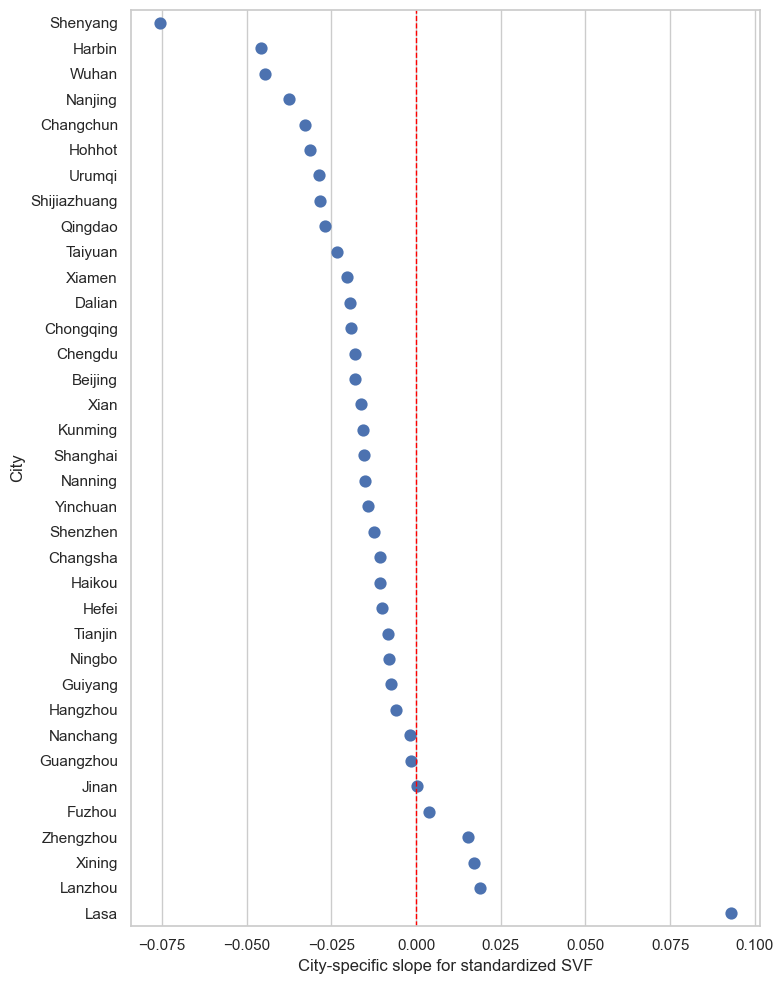

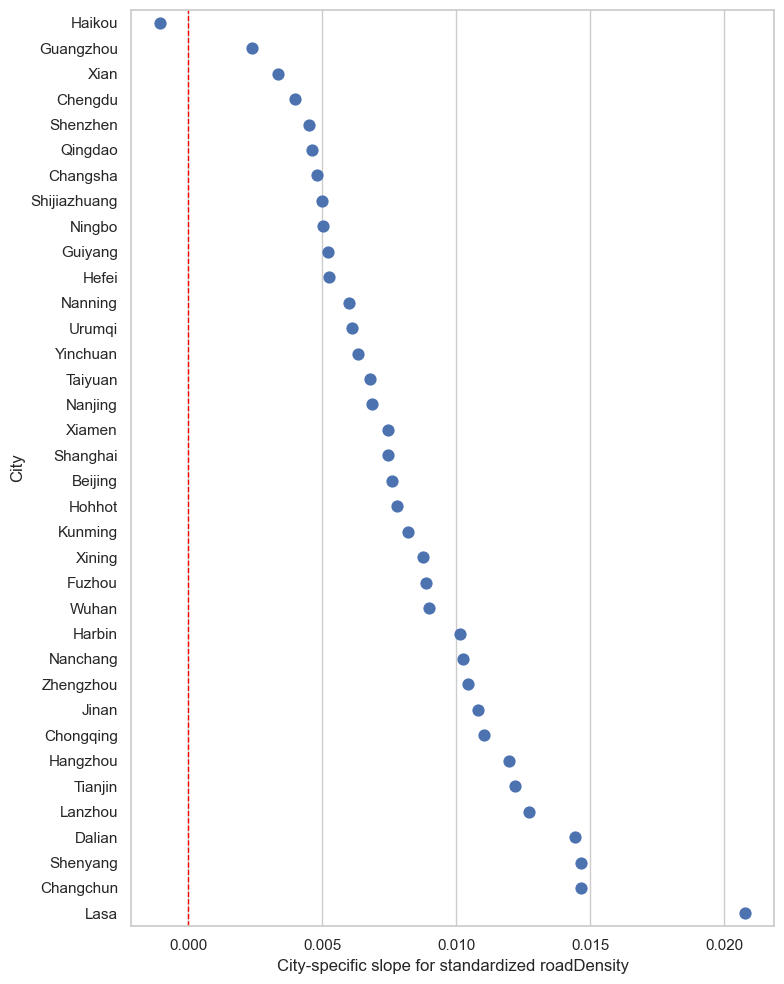

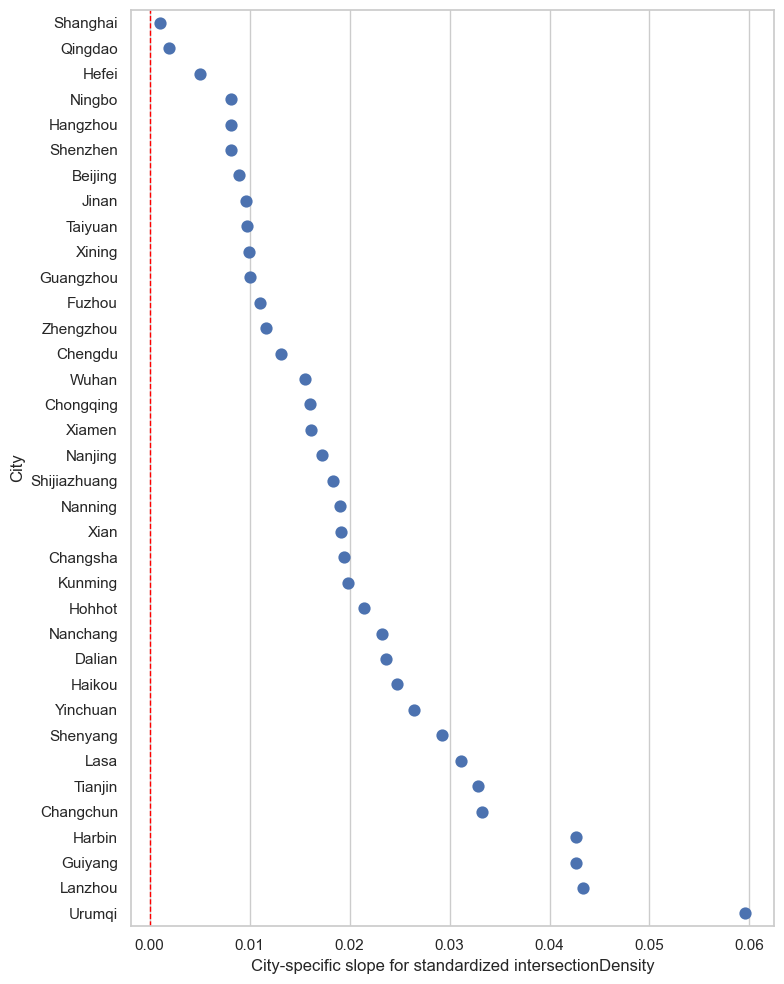

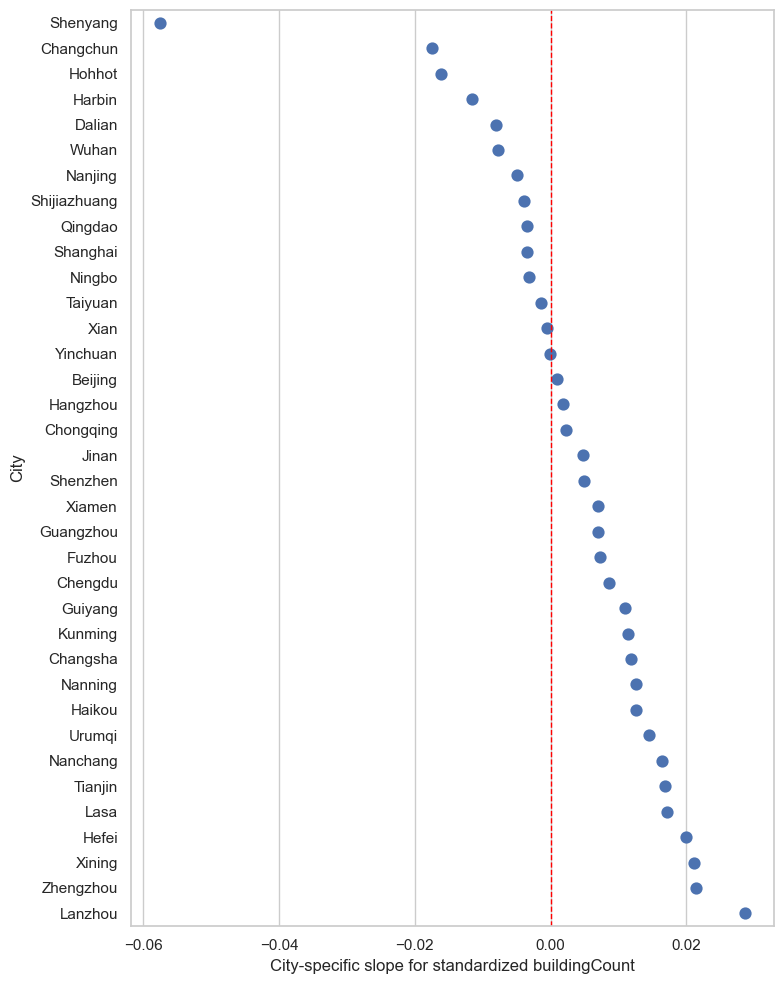

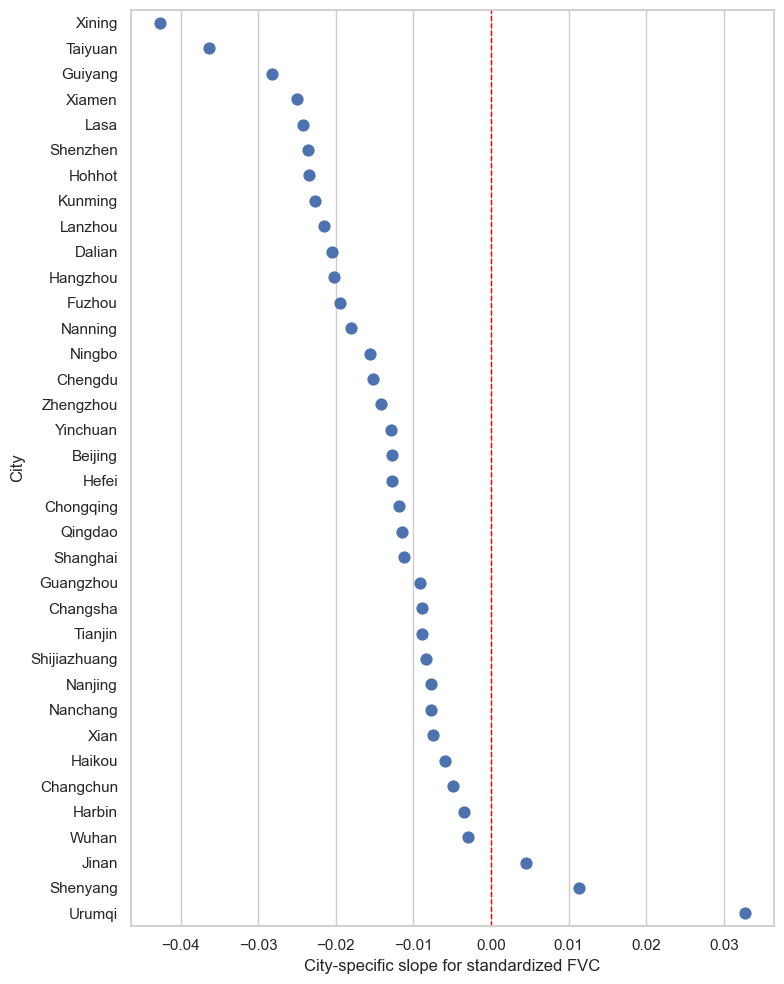

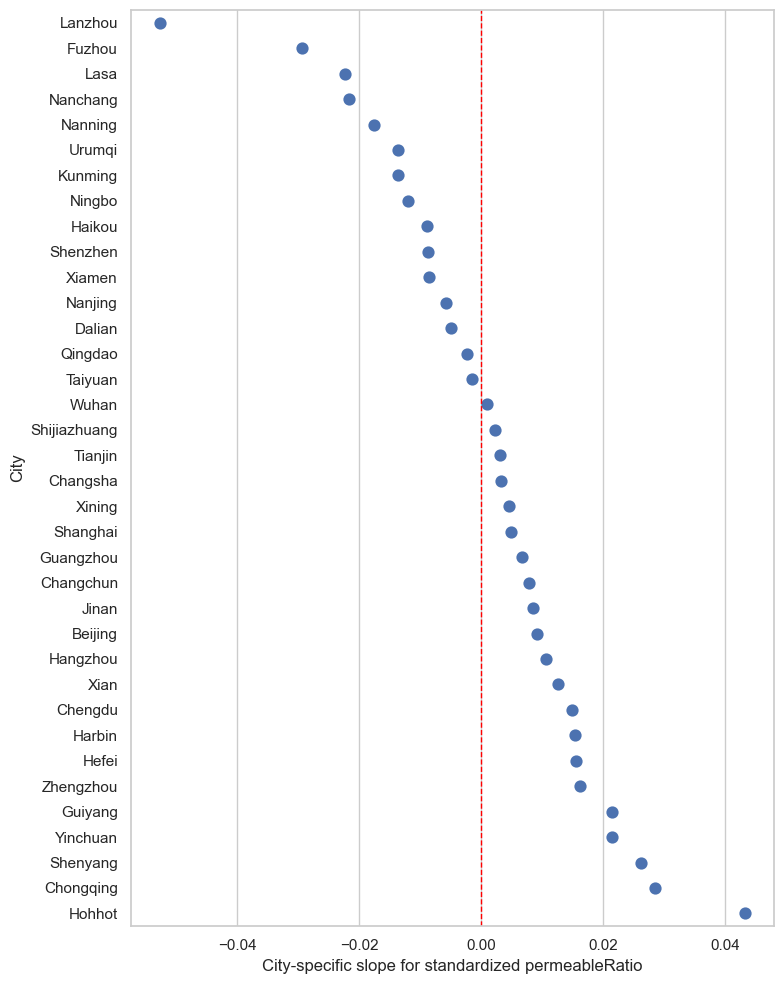

,City,term,feature,fixed_slope,random_slope_deviation,group_specific_slope
0,Beijing,SVF_z,SVF,-0.0132,-0.0048,-0.0180
1,Beijing,roadDensity_z,roadDensity,0.0082,-0.0006,0.0076
2,Beijing,intersectionDensity_z,intersectionDensity,0.0198,-0.0108,0.0089
3,Beijing,buildingCount_z,buildingCount,0.0034,-0.0025,0.0009
4,Beijing,FVC_z,FVC,-0.0131,0.0003,-0.0128


In [8]:
RUN_RANDOM_SLOPE_MODEL = True
MAX_RANDOM_SLOPE_FEATURES = 6
P_THRESHOLD_FOR_SLOPE_SELECTION = 0.05

PLANNING_PRIORITY = [
    'FAR', 'coverageRatio', 'SVF', 'roadDensity', 'intersectionDensity',
    'buildingCount', 'avgHeight', 'FVC', 'permeableRatio', 'compactness',
    'poiDensity', 'poiDiversity', 'streetRatio', 'largestPatchIndex'
]


def choose_random_slope_features(coef_table, z_terms, planning_priority, max_features=6, p_threshold=0.05):
    available = [term.replace('_z', '') for term in z_terms]
    significant_terms = coef_table.loc[
        (coef_table['p_value'] < p_threshold) & (coef_table['term'].isin(z_terms)),
        'term'
    ].tolist()

    chosen = [
        f for f in planning_priority
        if f in available and f'{f}_z' in significant_terms
    ]

    for f in planning_priority:
        if len(chosen) >= max_features:
            break
        if f in available and f not in chosen:
            chosen.append(f)

    return chosen[:max_features]


def fit_and_plot_random_slopes(data, formula, group_col, selected_features, out_dir):
    if len(selected_features) == 0:
        print('No selected random-slope features.')
        return None, None

    slope_terms = [f'{f}_z' for f in selected_features]
    re_formula = '1 + ' + ' + '.join(slope_terms)

    slope_result = fit_mixedlm(
        formula=formula,
        data=data,
        group_col=group_col,
        re_formula=re_formula,
        model_name='city random-slope model for raw features'
    )

    slope_coef = coefficient_table(slope_result)
    slope_r2 = pd.DataFrame([mixedlm_r2(slope_result)])
    slope_coef.to_csv(f'{out_dir}/city_random_slope_coefficients.csv', index=False)
    slope_r2.to_csv(f'{out_dir}/city_random_slope_r2.csv', index=False)
    with open(f'{out_dir}/city_random_slope_summary.txt', 'w', encoding='utf-8') as f:
        f.write(slope_result.summary().as_text())

    rows = []
    random_effects = slope_result.random_effects
    for group, effects in random_effects.items():
        for term in slope_terms:
            fixed_slope = slope_result.fe_params.get(term, np.nan)
            random_slope = effects.get(term, 0.0)
            rows.append({
                group_col: group,
                'term': term,
                'feature': term.replace('_z', ''),
                'fixed_slope': fixed_slope,
                'random_slope_deviation': random_slope,
                'group_specific_slope': fixed_slope + random_slope
            })

    slopes = pd.DataFrame(rows)
    slopes.to_csv(f'{out_dir}/city_specific_random_slopes.csv', index=False)

    for feature in selected_features:
        plot_df = slopes[slopes['feature'] == feature].sort_values('group_specific_slope')
        plt.figure(figsize=(8, 10))
        sns.pointplot(data=plot_df, x='group_specific_slope', y=group_col, join=False)
        plt.axvline(0, color='red', linestyle='--', linewidth=1)
        plt.xlabel(f'City-specific slope for standardized {feature}')
        plt.ylabel(group_col)
        plt.tight_layout()
        plt.savefig(f'{out_dir}/city_random_slopes_{feature}.png', dpi=300, bbox_inches='tight')
        plt.show()

    return slope_result, slopes


random_slope_features = choose_random_slope_features(
    coef_table=main_coef,
    z_terms=z_terms,
    planning_priority=PLANNING_PRIORITY,
    max_features=MAX_RANDOM_SLOPE_FEATURES,
    p_threshold=P_THRESHOLD_FOR_SLOPE_SELECTION
)
print('Random-slope features:', random_slope_features)

if RUN_RANDOM_SLOPE_MODEL:
    try:
        slope_result, city_slopes = fit_and_plot_random_slopes(
            data=df_ml,
            formula=main_formula,
            group_col=GROUP_COL,
            selected_features=random_slope_features,
            out_dir=OUT_DIR
        )
        if city_slopes is not None:
            display(city_slopes.head())
    except Exception as err:
        print('Random-slope model or plotting failed:')
        print(err)
        print('Try lowering MAX_RANDOM_SLOPE_FEATURES, for example to 2 or 3.')
else:
    print('Random-slope model skipped.')

## 7. Diagnostics

Prediction type: fixed_only_singular_random_effects


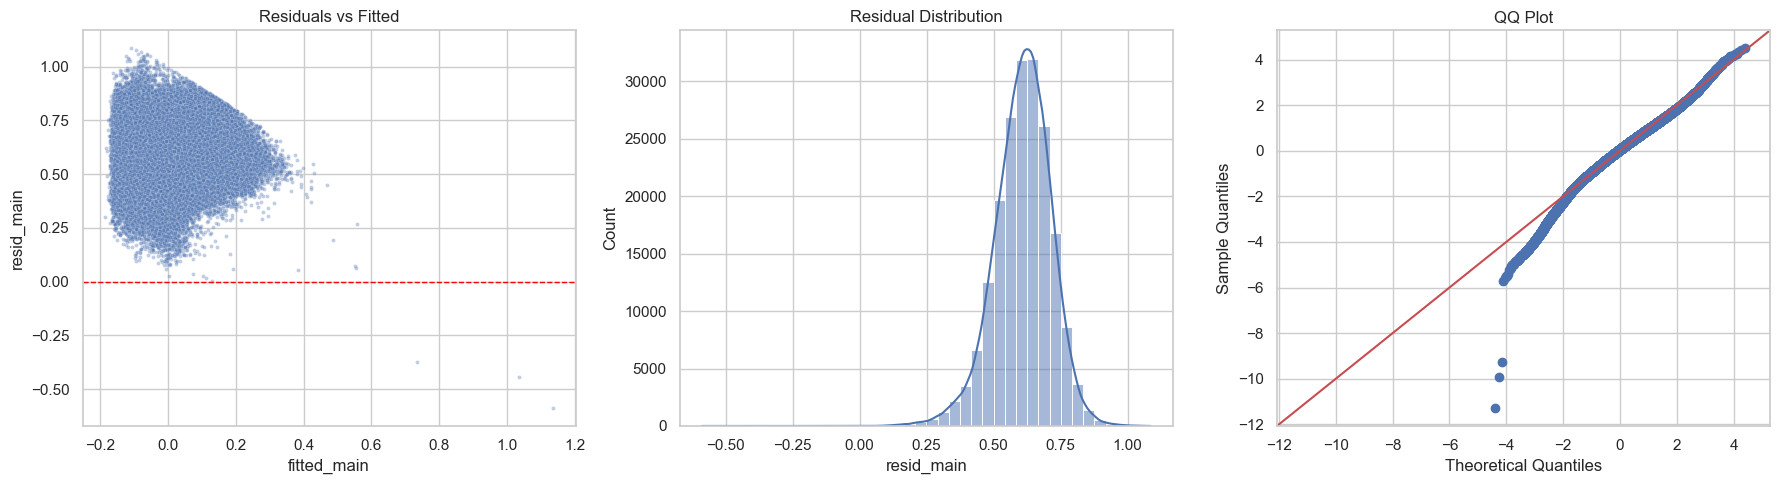

In [9]:
df_ml['fitted_main'], df_ml['resid_main'], prediction_type = safe_mixedlm_predictions(
    main_result,
    y=df_ml[TARGET].values
)
print('Prediction type:', prediction_type)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.scatterplot(data=df_ml, x='fitted_main', y='resid_main', s=8, alpha=0.35, ax=axes[0])
axes[0].axhline(0, color='red', linestyle='--', linewidth=1)
axes[0].set_title('Residuals vs Fitted')
sns.histplot(df_ml['resid_main'], bins=40, kde=True, ax=axes[1])
axes[1].set_title('Residual Distribution')
sm.qqplot(df_ml['resid_main'], line='45', fit=True, ax=axes[2])
axes[2].set_title('QQ Plot')
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/main_raw_city_residual_diagnostics.png', dpi=300, bbox_inches='tight')
plt.show()